In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Hochschule Emden/Leer' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/01bc76c69' -- 'Hochschule Emden/Leer'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Hochschule Emden/Leer,University of Applied Sciences Emden-Leer,https://openalex.org/W4226146043
1,not assigned,Hochschule Emden/Leer,"Hochschule Emden/Leer, University of Applied S...",https://openalex.org/W4213106780
2,not assigned,Hochschule Emden/Leer,"Faculty of Technology, Molecular Biosciences, ...",https://openalex.org/W4221015681
3,not assigned,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Fac...",https://openalex.org/W4211099579
4,not assigned,Hochschule Emden/Leer,University of Applied Sciences Emden/Leer,https://openalex.org/W4313590954


In [112]:
MAPPING_DICT = {
    'Fachbereich Seefahrt und maritime Wissenschaften': ['maritime (sciences|mobility)', 'nautical'],
    'Fachbereich Soziale Arbeit und Gesundheit': ['so(z|c)ial', 'public health', 'life sciences'],
    'Fachbereich Technik': ['technology', 'engineering', 'laser', 'informatic', 'energies', 'fachbereich technik', 'machine dynamics', 'maschinendynamik',
                            'solar energy', 'mixed reality lab'
                           ],
    'Fachbereich Wirtschaft': ['wirtschaft', 'business', 'finanzmanagement', 'economics']
    # 'Hochschulbibliothek': [''],
}

In [113]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [114]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [115]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,None,Hochschule Emden/Leer,University of Applied Sciences Emden-Leer,https://openalex.org/W4226146043
1,None,Hochschule Emden/Leer,"Hochschule Emden/Leer, University of Applied S...",https://openalex.org/W4213106780
2,Fachbereich Technik,Hochschule Emden/Leer,"Faculty of Technology, Molecular Biosciences, ...",https://openalex.org/W4221015681
3,Fachbereich Seefahrt und maritime Wissenschaften,Hochschule Emden/Leer,"University of Applied Sciences Emden/Leer, Fac...",https://openalex.org/W4211099579
4,None,Hochschule Emden/Leer,University of Applied Sciences Emden/Leer,https://openalex.org/W4313590954
...,...,...,...,...
396,Fachbereich Soziale Arbeit und Gesundheit,Hochschule Emden/Leer,Fachbereich Soziale Arbeit und Gesundheit Hoch...,https://openalex.org/W3175657145
397,Fachbereich Technik,Hochschule Emden/Leer,"Institute for Industrial Informatics, Automati...",https://openalex.org/W4292258978
398,Fachbereich Soziale Arbeit und Gesundheit,Hochschule Emden/Leer,"Department of Social Work and Health, Universi...",https://openalex.org/W3092072900
399,Fachbereich Technik,Hochschule Emden/Leer,"Faculty of Technology, University of Applied S...",https://openalex.org/W3092326892


In [116]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()

array(['University of Applied Sciences Emden-Leer',
       'Hochschule Emden/Leer, University of Applied Sciences Emden/Leer, Emden, Germany',
       'University of Applied Sciences Emden/Leer',
       'University of Applied Science Emden/Leer (Germany)',
       'University of Applied Sciences Emden Leer',
       'Hochschule Emden/Leer, Constantiaplatz 4, 26723 Emden, Germany',
       '2 Hochschule Emden/Leer, Constantiaplatz 4, 26723 Emden, Germany',
       'University of Emden/Leer, Emden, Germany',
       'University of Emden/Leer , Emden,',
       'University of Applied Sciences Emden/Leer , Emden, Germany',
       'Hochschule Emden-Leer, Emden, Germany',
       'University Emden/Leer, Emden, Germany',
       'Hochschule Emden/Leer, University of Applied Sciences, Emden, Germany',
       'Hochschule Emden/Leer, University of Applied Sciences,Emden,Germany',
       'Univ. of Applied Sciences Emden (Germany)',
       'Hochschule Emden/Leer, Emden/Leer',
       'University of Applied 

In [117]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Fachbereich Seefahrt und maritime Wissenschaften,8
1,Fachbereich Soziale Arbeit und Gesundheit,62
2,Fachbereich Technik,128
3,Fachbereich Wirtschaft,8
4,NaN,195


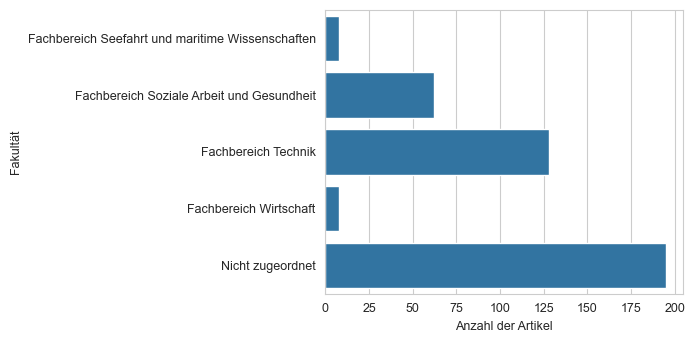

In [118]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 3.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [119]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.513715710723192